In [1]:
import ast
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\bryan\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_da_us=df_da_us.dropna(subset=['salary_year_avg'])
df_da_us_exploded=df_da_us.explode('job_skills')
df_da_us_exploded[['salary_year_avg', 'job_skills']].head(5)
df_da_skills=df_da_us_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_da_skills=df_da_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})


In [3]:
da_job_count=len(df_da_us)
df_da_skills['skill_percent']=df_da_skills['skill_count']/da_job_count*100
df_da_skills
skill_percent=5
df_da_skills_high_demand=df_da_skills[df_da_skills['skill_percent'] > skill_percent]

In [14]:
df_technology=df['job_type_skills'].copy()
df_technology=df_technology.drop_duplicates()
df_technology=df_technology.dropna()

technology_dict={}
for row in df_technology:
    row_dict=ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

df_technology= pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])
df_technology=df_technology.explode('skills')

df_plot=df_da_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

    

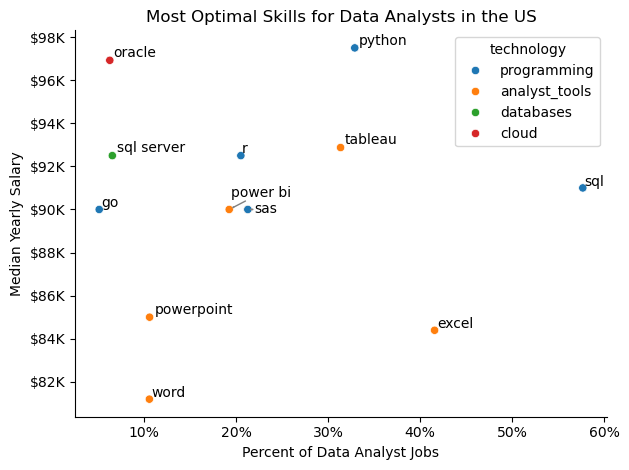

In [17]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter
sns.scatterplot(data=df_plot, x='skill_percent', y='median_salary', hue='technology')
sns.despine()
texts= []

for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(plt.text(df_da_skills_high_demand['skill_percent'].iloc[i], df_da_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.tight_layout()
plt.show()